# 🧠 Neural Networks From Scratch
## A First-Timer's Complete Guide to Loss Functions, Gradient Descent & Backpropagation

---

> *"The best way to understand something deep is to build it from the ground up, with your own hands."*

---

### Who This Notebook Is For

This notebook is written for **you** — someone who has heard terms like "backpropagation" or "gradient descent" and wants to finally understand what they *actually mean*, not just memorise a definition.

We will use **zero deep learning libraries**. No PyTorch. No TensorFlow. Just Python and NumPy. Every line of code will be explained in plain language before it is written.

By the end of this notebook you will be able to:
- Explain what a loss function is to a complete beginner — using a real-world story
- Describe intuitively why gradient descent works
- Trace the exact path a gradient takes through a network during backpropagation
- Build a working neural network from scratch that solves a real problem

### Roadmap

```
PART 1 ── What Is a Loss Function?
           (the story, the math, the code, the visualisation)

PART 2 ── Gradient Descent
           (the hiking analogy, the math, the code, the visualisation)

PART 3 ── Backpropagation
           (the chain rule, layer by layer, in slow motion)

PART 4 ── Putting It All Together
           (build a full network, train it, watch it learn)

PART 5 ── Notes You Can Keep
           (a summary written to be copied into your notebook)
```

Let's go.

---
## Setup — Importing Our Tools

We only need two libraries for this entire notebook:

- **`numpy`** — for fast matrix math (adding, multiplying arrays of numbers efficiently)
- **`matplotlib`** — for drawing graphs

We also call `np.random.seed(42)`. This is like picking a specific starting point for all of our random number generation — it means if you close this notebook and reopen it, you will get **exactly the same results** every time. It is a reproducibility habit every practitioner uses.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

np.random.seed(42)

print("✅ Libraries loaded. Let's build a brain.")

✅ Libraries loaded. Let's build a brain.


---
# PART 1 — What Is a Loss Function?

---

## 1.1 The Story: A Student Taking Exams

Imagine a student named **Amara** who is studying for a maths exam. Every week, her teacher gives her a practice test and then marks her work.

The teacher doesn't just say "you are wrong" — the teacher gives her a **specific score** that tells her *how far* she is from the correct answer.

| Amara's Answer | Correct Answer | How Far Off? |
|:-:|:-:|:-:|
| 95 | 100 | off by 5 |
| 40 | 100 | off by 60 |
| 99 | 100 | off by 1 |

The "how far off" number is exactly what a **loss function** is in machine learning.

> **A loss function is a score that tells the model: "This is how wrong you currently are."**

The **lower** the loss, the **better** the model. A loss of zero would mean the model is perfect.

---

## 1.2 Why "Loss" and Not Just "Error"?

Think of the word "loss" literally. When you make a wrong prediction, you *lose* something — accuracy, trust, money (in a real business system). The loss function **quantifies that penalty** in a way the computer can do maths with.

Different situations call for different ways of measuring loss. Here are the two most common:

---

### Loss Function #1: Mean Squared Error (MSE)

**The scenario:** You are predicting *how tall* a child will be when they grow up. The answer is a continuous number (say, 1.72 metres). When you are wrong, the loss should be proportional to how far off you were.

**The formula:**

$$\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i)^2$$

**In plain English:**
1. For each example, subtract the predicted value from the true value
2. Square that difference (this makes negatives positive, and punishes big errors more)
3. Average everything together

**Why do we square it?**
- If you predicted 5 and the answer is 3, you are off by 2
- If you predicted 1 and the answer is 3, you are also off by 2
- Without squaring, these cancel out when averaged: (5-3) + (1-3) = 2 + (-2) = 0 — which would falsely suggest no error!
- Squaring: (2)² + (-2)² = 4 + 4 = 8 — gives an honest score
- Squaring also means being *very* wrong is punished *much* more harshly than being a little wrong. An error of 10 gives a squared penalty of 100; an error of 1 gives only 1. The model is strongly motivated to fix its biggest mistakes first.

---

### Loss Function #2: Binary Cross-Entropy (BCE)

**The scenario:** You are classifying an email as spam (1) or not spam (0). The answer is a binary choice. Your model outputs a probability — a number between 0 and 1 — representing how confident it is that the email is spam.

**The formula:**

$$\text{BCE} = -\frac{1}{n} \sum_{i=1}^{n} \left[ y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \right]$$

**In plain English:**
- If the true answer is 1 (is spam): the loss is $-\log(\hat{y})$
  - If the model says 0.99 (very confident spam): loss ≈ 0.01 — tiny penalty ✅
  - If the model says 0.01 (thinks it's not spam): loss ≈ 4.6 — massive penalty ❌
- If the true answer is 0 (not spam): the loss is $-\log(1 - \hat{y})$
  - Same logic in reverse

The `log` function naturally makes the penalty *explode* when the model is confidently wrong, which forces it to be humble and accurate.

---

**In this notebook we use MSE** because it has a clean, intuitive gradient that makes the backpropagation maths easy to follow. Once you understand MSE, BCE is the same logic.

In [2]:
# ─────────────────────────────────────────────────────────────────
# IMPLEMENTING THE LOSS FUNCTIONS
# ─────────────────────────────────────────────────────────────────

def mse_loss(predictions, targets):
    """
    Mean Squared Error.
    
    predictions : model's guesses, shape (n, 1)
    targets     : true answers,    shape (n, 1)
    returns     : single scalar loss value
    """
    # Step 1: Compute the error for each example
    errors = predictions - targets          # shape: (n, 1)
    
    # Step 2: Square each error
    squared_errors = errors ** 2            # shape: (n, 1)
    
    # Step 3: Take the average, scaled by 0.5
    # (The 0.5 is a mathematical convenience — it cancels neatly
    #  with the exponent 2 when we take the derivative later)
    return np.mean(0.5 * squared_errors)    # scalar


def bce_loss(predictions, targets):
    """
    Binary Cross-Entropy Loss.
    predictions are clipped to avoid log(0) = -infinity.
    """
    eps = 1e-15   # tiny number to avoid numerical instability
    predictions = np.clip(predictions, eps, 1 - eps)
    return -np.mean(
        targets * np.log(predictions) + (1 - targets) * np.log(1 - predictions)
    )


# ── Quick demo ───────────────────────────────────────────────────
print("=" * 55)
print("LOSS FUNCTION DEMO")
print("=" * 55)

true_answer   = np.array([[1.0]])   # True label: positive/spam

scenarios = [
    ("Model is very confident and CORRECT",   np.array([[0.99]])),
    ("Model is uncertain (50/50 guess)",       np.array([[0.50]])),
    ("Model is very confident but WRONG",      np.array([[0.01]])),
]

for description, pred in scenarios:
    loss = bce_loss(pred, true_answer)
    print(f"\n  📌 {description}")
    print(f"     Prediction: {pred[0][0]:.2f}  |  BCE Loss: {loss:.4f}")

LOSS FUNCTION DEMO

  📌 Model is very confident and CORRECT
     Prediction: 0.99  |  BCE Loss: 0.0101

  📌 Model is uncertain (50/50 guess)
     Prediction: 0.50  |  BCE Loss: 0.6931

  📌 Model is very confident but WRONG
     Prediction: 0.01  |  BCE Loss: 4.6052


---
## 1.3 Visualising the Loss Landscape

Here is one of the most important mental pictures in all of machine learning.

Imagine your model has **one single adjustable weight** — call it `w`. For every possible value of `w`, there is a corresponding loss value. If we plot `w` on the x-axis and loss on the y-axis, we get a **loss curve**.

The model's job is to **find the value of `w` that sits at the bottom of the curve** — the lowest possible loss.

How it finds that bottom point is the job of **Gradient Descent** (Part 2).

The cell below draws this picture for you.

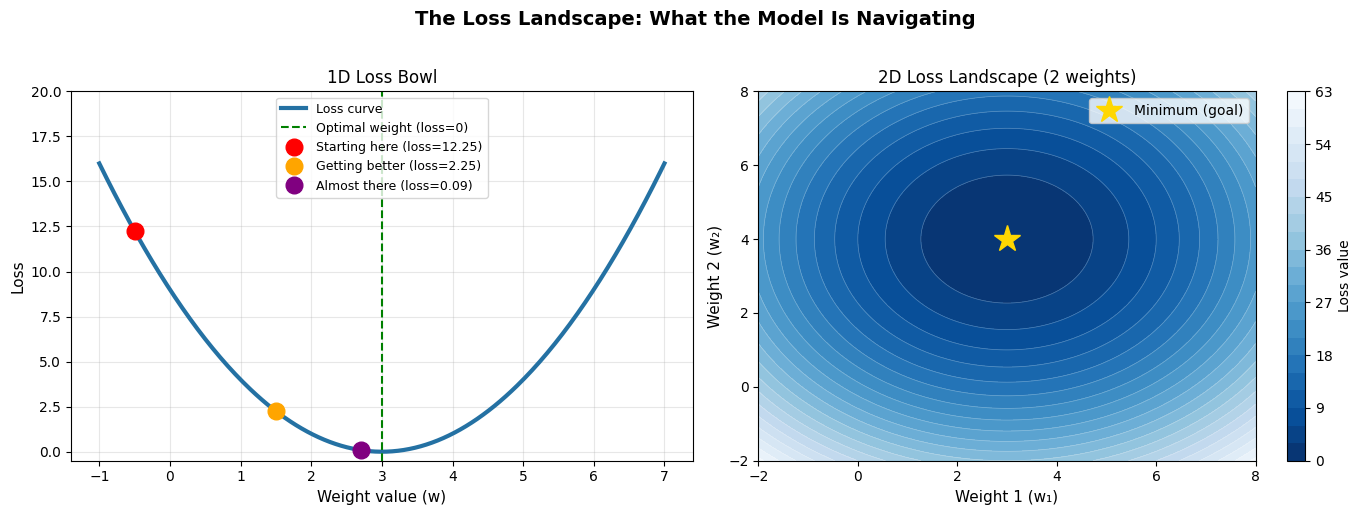


📖 What you're seeing:
  LEFT  — With one weight, the loss is a simple bowl (parabola).
          The bottom of the bowl is where loss = 0.
  RIGHT — With two weights, the loss is a bowl in 3D space.
          Darker = lower loss. The gold star is the target.
  Real networks have MILLIONS of weights — same idea, more dimensions.


In [3]:
# ─────────────────────────────────────────────────────────────────
# VISUALISING THE LOSS LANDSCAPE
# ─────────────────────────────────────────────────────────────────

# Imagine a single-weight toy model where the true answer is w=3.0
# Loss = (w - 3.0)^2  — a simple parabola
w_values = np.linspace(-1, 7, 300)
loss_values = (w_values - 3.0) ** 2

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("The Loss Landscape: What the Model Is Navigating",
             fontsize=14, fontweight='bold', y=1.02)

# ── Left plot: the loss bowl ──────────────────────────────────────
ax = axes[0]
ax.plot(w_values, loss_values, color='#2471A3', linewidth=3, label='Loss curve')
ax.axvline(x=3.0, color='green', linestyle='--', linewidth=1.5, label='Optimal weight (loss=0)')

# Mark three different starting positions
positions = [(-0.5, 'red', 'Starting here (loss=12.25)'),
             (1.5,  'orange', 'Getting better (loss=2.25)'),
             (2.7,  'purple', 'Almost there (loss=0.09)')]

for w_pos, colour, label in positions:
    l_pos = (w_pos - 3.0) ** 2
    ax.plot(w_pos, l_pos, 'o', color=colour, markersize=12, label=label, zorder=5)

ax.set_xlabel("Weight value (w)", fontsize=11)
ax.set_ylabel("Loss", fontsize=11)
ax.set_title("1D Loss Bowl", fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.5, 20)

# ── Right plot: 2D loss landscape (two weights) ───────────────────
ax2 = axes[1]
w1 = np.linspace(-2, 8, 200)
w2 = np.linspace(-2, 8, 200)
W1, W2 = np.meshgrid(w1, w2)
Z = (W1 - 3.0)**2 + (W2 - 4.0)**2   # bowl centred at (3, 4)

contour = ax2.contourf(W1, W2, Z, levels=20, cmap='Blues_r')
ax2.contour(W1, W2, Z, levels=20, colors='white', alpha=0.3, linewidths=0.5)
plt.colorbar(contour, ax=ax2, label='Loss value')
ax2.plot(3.0, 4.0, '*', color='gold', markersize=20, label='Minimum (goal)', zorder=5)
ax2.set_xlabel("Weight 1 (w₁)", fontsize=11)
ax2.set_ylabel("Weight 2 (w₂)", fontsize=11)
ax2.set_title("2D Loss Landscape (2 weights)", fontsize=12)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.savefig('loss_landscape.png', dpi=120, bbox_inches='tight')
plt.show()

print()
print("📖 What you're seeing:")
print("  LEFT  — With one weight, the loss is a simple bowl (parabola).")
print("          The bottom of the bowl is where loss = 0.")
print("  RIGHT — With two weights, the loss is a bowl in 3D space.")
print("          Darker = lower loss. The gold star is the target.")
print("  Real networks have MILLIONS of weights — same idea, more dimensions.")

---
# PART 2 — Gradient Descent: Walking Down the Hill

---

## 2.1 The Hiker Analogy

Picture yourself standing somewhere on a hilly mountain in thick fog. You cannot see more than a metre in any direction. Your goal is to reach the lowest valley.

How do you move?

> **You feel the ground beneath your feet. You take one step in the direction it slopes downward. Then you repeat.**

That is **gradient descent** — exactly as described, but for mathematics.

- The **mountain** is the loss landscape (the bowl you saw above)
- **Your position** is the current value of the model's weights
- **Feeling the slope** is computing the gradient (derivative) of the loss
- **Taking a step downhill** is updating the weights

---

## 2.2 What Is a Gradient?

A **gradient** is just a slope — how steeply the loss changes when you nudge a weight.

More precisely:

> If weight `w` increases by a tiny amount, how much does the loss change?

We write this as $\frac{\partial L}{\partial w}$ — "the partial derivative of loss with respect to weight w".

**Intuitive examples:**

| Gradient value | What it means |
|:-:|:---|
| **+5.0** | If you increase `w`, loss goes up sharply. You should **decrease** `w`. |
| **-3.0** | If you increase `w`, loss goes down. You should **increase** `w`. |
| **0.0** | Flat ground. You are at the minimum! |
| **+0.001** | Very gently sloping upward. You are very close to the minimum. |

The update rule is:

$$w_{\text{new}} = w_{\text{old}} - \eta \cdot \frac{\partial L}{\partial w}$$

The minus sign is crucial. We **subtract** the gradient because we want to go *downhill*. If the gradient is positive (uphill to the right), we move left (decrease `w`).

$\eta$ ("eta") is the **learning rate** — how big a step we take.

---

## 2.3 The Learning Rate: Step Size Matters

This is one of the most important and tricky hyperparameters in deep learning.

**Too large** — You overshoot the valley. You jump past the minimum and land on the other side, then jump back, then forward again... You never settle.

**Too small** — Every step is tiny. You will eventually reach the valley, but it will take forever. In practice, training could run for days and still not converge.

**Just right** — Smooth, steady descent into the valley.

The cell below animates all three scenarios so you can *see* this.

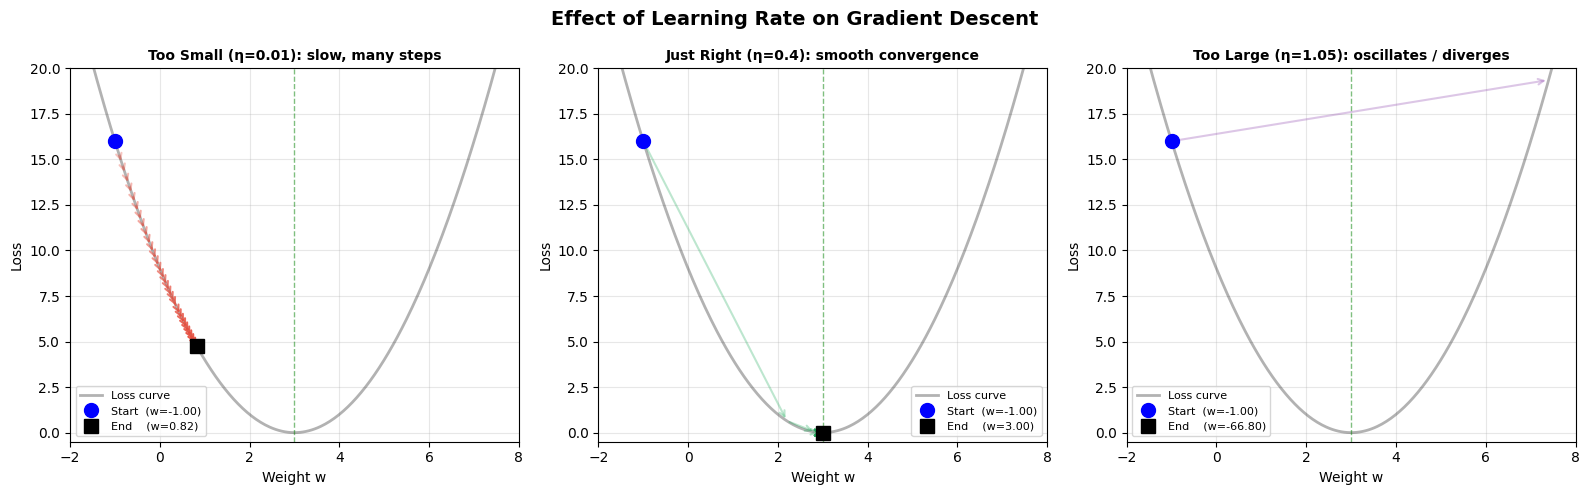

📖 Observations:
  RED   (too small) : moves correctly but crawls. Takes many steps to converge.
  GREEN (just right): each step moves meaningfully toward the minimum.
  PURPLE (too large): overshoots past the minimum — may never settle.


In [4]:
# ─────────────────────────────────────────────────────────────────
# GRADIENT DESCENT: VISUALISING STEP SIZE EFFECTS
# ─────────────────────────────────────────────────────────────────

def gradient_descent_trace(start_w, learning_rate, steps=25):
    """
    Simulate gradient descent on loss(w) = (w - 3)^2.
    The true minimum is at w = 3.
    
    Gradient of (w-3)^2 is 2*(w-3).
    """
    w = start_w
    history = [w]
    for _ in range(steps):
        gradient = 2 * (w - 3.0)       # dL/dw
        w = w - learning_rate * gradient   # update rule
        history.append(w)
    return history


# Three learning rate experiments
configs = [
    (0.01,  '#E74C3C', 'Too Small (η=0.01): slow, many steps'),
    (0.4,   '#27AE60', 'Just Right (η=0.4): smooth convergence'),
    (1.05,  '#8E44AD', 'Too Large (η=1.05): oscillates / diverges'),
]

w_plot = np.linspace(-2, 8, 300)
loss_plot = (w_plot - 3.0) ** 2

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Effect of Learning Rate on Gradient Descent",
             fontsize=14, fontweight='bold')

for ax, (lr, colour, title) in zip(axes, configs):
    trace = gradient_descent_trace(start_w=-1.0, learning_rate=lr, steps=30)
    trace_losses = [(w - 3.0)**2 for w in trace]
    
    # Draw the loss bowl
    ax.plot(w_plot, loss_plot, 'k-', linewidth=2, alpha=0.3, label='Loss curve')
    ax.axvline(x=3.0, color='green', linestyle='--', alpha=0.5, linewidth=1)
    
    # Draw the descent path as arrows
    for i in range(len(trace) - 1):
        alpha = 0.3 + 0.7 * (i / len(trace))   # fades in
        ax.annotate("",
            xy    =(trace[i+1], trace_losses[i+1]),
            xytext=(trace[i],   trace_losses[i]),
            arrowprops=dict(arrowstyle="->", color=colour, alpha=alpha, lw=1.5)
        )
    
    ax.plot(trace[0],  trace_losses[0],  'o', color='blue',  markersize=10,
            label=f'Start  (w={trace[0]:.2f})', zorder=5)
    ax.plot(trace[-1], trace_losses[-1], 's', color='black', markersize=10,
            label=f'End    (w={trace[-1]:.2f})', zorder=5)
    
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel("Weight w", fontsize=10)
    ax.set_ylabel("Loss", fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.5, 20)
    ax.set_xlim(-2, 8)

plt.tight_layout()
plt.savefig('gradient_descent_lr.png', dpi=120, bbox_inches='tight')
plt.show()

print("📖 Observations:")
print("  RED   (too small) : moves correctly but crawls. Takes many steps to converge.")
print("  GREEN (just right): each step moves meaningfully toward the minimum.")
print("  PURPLE (too large): overshoots past the minimum — may never settle.")

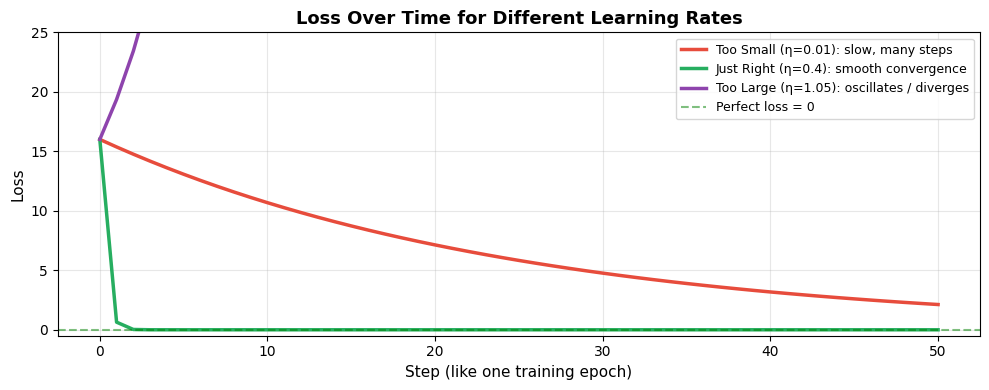


Notice: the GREEN line (good learning rate) descends smoothly to zero.
The PURPLE line bounces — it cannot settle. This is called 'divergence'.


In [5]:
# ─────────────────────────────────────────────────────────────────
# GRADIENT DESCENT: LOSS OVER TIME
# ─────────────────────────────────────────────────────────────────
# Let's also watch the loss VALUE drop as training progresses.

fig, ax = plt.subplots(figsize=(10, 4))

for lr, colour, title in configs:
    trace = gradient_descent_trace(start_w=-1.0, learning_rate=lr, steps=50)
    losses_over_time = [(w - 3.0)**2 for w in trace]
    ax.plot(losses_over_time, color=colour, linewidth=2.5, label=title)

ax.axhline(y=0, color='green', linestyle='--', alpha=0.5, label='Perfect loss = 0')
ax.set_title("Loss Over Time for Different Learning Rates", fontsize=13, fontweight='bold')
ax.set_xlabel("Step (like one training epoch)", fontsize=11)
ax.set_ylabel("Loss", fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.5, 25)

plt.tight_layout()
plt.show()

print()
print("Notice: the GREEN line (good learning rate) descends smoothly to zero.")
print("The PURPLE line bounces — it cannot settle. This is called 'divergence'.")

---
# PART 3 — Backpropagation: Teaching a Network To Learn

---

## 3.1 Why Do We Even Need Backpropagation?

In Part 2, gradient descent was easy: we had one weight, and we could write down its gradient directly.

But a real neural network has **many layers** stacked on top of each other. The first layer's weights are far away from the loss. How do we know how to update them?

**The problem:** We can only measure the loss at the very *end* of the network (the output). But the weights we need to update are scattered across every layer.

**The solution:** Backpropagation routes the error signal backwards through the network, layer by layer, using the **chain rule** from calculus.

---

## 3.2 The Chain Rule — In Human Language

The chain rule sounds scary, but here's an everyday version:

> **Scenario:** A car's speed affects fuel consumption. Fuel consumption affects cost. How does the car's speed affect cost?
>
> Answer: `(how speed affects fuel) × (how fuel affects cost)`

In maths:
$$\frac{d(\text{cost})}{d(\text{speed})} = \frac{d(\text{cost})}{d(\text{fuel})} \times \frac{d(\text{fuel})}{d(\text{speed})}$$

That multiplication of derivatives flowing backwards through a chain of causes — that is the chain rule, and that is backpropagation.

For a neural network with layers A → B → C → Loss:
$$\frac{\partial L}{\partial w_A} = \frac{\partial L}{\partial C} \cdot \frac{\partial C}{\partial B} \cdot \frac{\partial B}{\partial w_A}$$

We compute this product by starting at the loss and working our way backwards.

---

## 3.3 The Sigmoid Activation — A Non-Linearity Gate

Before we implement layers, we need an **activation function**. Without it, stacking layers is useless — a stack of linear transformations is still just one linear transformation. Activations introduce *bends* into the function, allowing the network to model complex, curved relationships.

We use **Sigmoid**, defined as:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

It squashes any input to the range (0, 1) — it interprets raw scores as probabilities.

Its derivative is famously clean:

$$\sigma'(z) = \sigma(z) \cdot (1 - \sigma(z))$$

In code, if we already have `a = sigmoid(z)`, the derivative is just `a * (1 - a)`. No need to recompute anything from scratch — a beautiful property we use heavily in backprop.

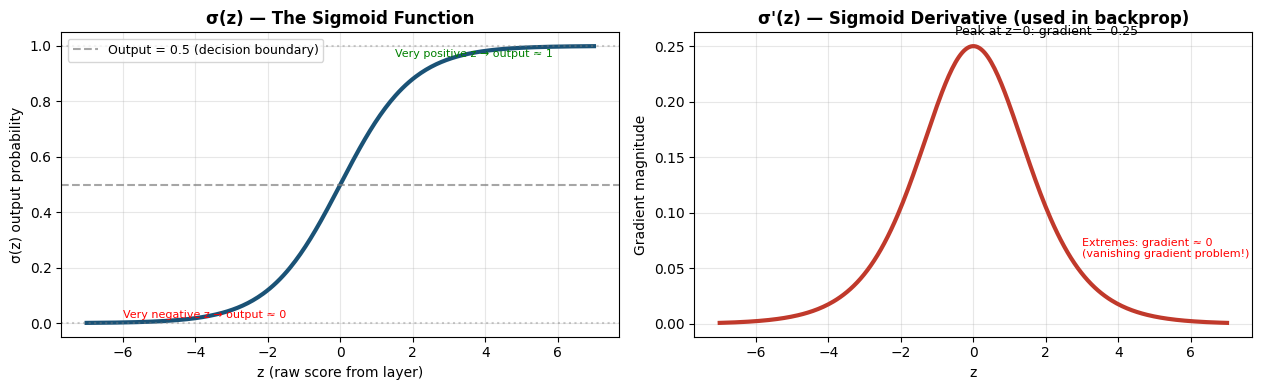

📖 What to notice about the derivative plot:
  The gradient is LARGEST near z=0 (good — learning is fast here).
  The gradient is near ZERO at the extremes.
  This causes 'vanishing gradients' in deep networks — one reason
  modern networks often prefer ReLU activation instead of sigmoid.


In [6]:
# ─────────────────────────────────────────────────────────────────
# THE SIGMOID ACTIVATION FUNCTION
# ─────────────────────────────────────────────────────────────────

def sigmoid(z):
    """Squashes any real number into (0, 1)."""
    return 1.0 / (1.0 + np.exp(-z))

def sigmoid_derivative(activated_output):
    """
    Derivative of sigmoid — given the ALREADY activated value `a = sigmoid(z)`.
    This is called during backpropagation. We reuse the cached activation
    instead of recomputing sigmoid(z) from scratch.
    """
    return activated_output * (1.0 - activated_output)


# ── Visualise sigmoid and its derivative ─────────────────────────
z_range = np.linspace(-7, 7, 300)
sig_vals = sigmoid(z_range)
sig_deriv = sigmoid_derivative(sig_vals)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Sigmoid itself
ax = axes[0]
ax.plot(z_range, sig_vals, color='#1A5276', linewidth=3)
ax.axhline(0.5, color='grey', linestyle='--', alpha=0.7, label='Output = 0.5 (decision boundary)')
ax.axhline(0.0, color='grey', linestyle=':',  alpha=0.4)
ax.axhline(1.0, color='grey', linestyle=':',  alpha=0.4)
ax.set_title("σ(z) — The Sigmoid Function", fontsize=12, fontweight='bold')
ax.set_xlabel("z (raw score from layer)", fontsize=10)
ax.set_ylabel("σ(z) output probability", fontsize=10)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.annotate("Very negative z → output ≈ 0", xy=(-6, 0.02), fontsize=8, color='red')
ax.annotate("Very positive z → output ≈ 1", xy=(1.5, 0.96), fontsize=8, color='green')

# Sigmoid derivative
ax2 = axes[1]
ax2.plot(z_range, sig_deriv, color='#C0392B', linewidth=3)
ax2.set_title("σ'(z) — Sigmoid Derivative (used in backprop)", fontsize=12, fontweight='bold')
ax2.set_xlabel("z", fontsize=10)
ax2.set_ylabel("Gradient magnitude", fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.annotate("Peak at z=0: gradient = 0.25", xy=(-0.5, 0.26), fontsize=9)
ax2.annotate("Extremes: gradient ≈ 0\n(vanishing gradient problem!)",
             xy=(3, 0.06), fontsize=8, color='red')

plt.tight_layout()
plt.savefig('sigmoid.png', dpi=120, bbox_inches='tight')
plt.show()

print("📖 What to notice about the derivative plot:")
print("  The gradient is LARGEST near z=0 (good — learning is fast here).")
print("  The gradient is near ZERO at the extremes.")
print("  This causes 'vanishing gradients' in deep networks — one reason")
print("  modern networks often prefer ReLU activation instead of sigmoid.")

---
## 3.4 Building a Dense Layer — Forward and Backward Pass

A **dense (fully connected) layer** does two things:

### Forward Pass
1. **Linear transformation:** `Z = X·W + B`
   - `X` — the input data (shape: batch × input_features)
   - `W` — the weight matrix (shape: input_features × output_neurons)
   - `B` — the bias vector (shape: 1 × output_neurons)
   - `Z` — the raw output scores (shape: batch × output_neurons)
2. **Activation:** `A = sigmoid(Z)`
   - `A` — the activated output sent to the next layer

### Backward Pass (Backpropagation)

The backward pass receives a gradient from the layer *above* it (called `dL/dA` — how the loss changes with respect to this layer's output) and computes three things:

1. **Gradient through activation:** `dL/dZ = dL/dA · σ'(Z)`
   - Applies the chain rule through the activation function
2. **Gradient for weights:** `dL/dW = Xᵀ · dL/dZ`
   - Used by gradient descent to update W
3. **Gradient for biases:** `dL/dB = sum(dL/dZ)`
   - Used by gradient descent to update B
4. **Gradient passed down:** `dL/dX = dL/dZ · Wᵀ`
   - Sent to the layer *below* this one, so it can compute its own gradients

### Why do we cache during the forward pass?

The backward pass needs values that were computed during the forward pass (`X` and `A`). We *cache* (store) them during forward so they are available during backward. This is a universal design pattern in deep learning frameworks.

In [7]:
# ─────────────────────────────────────────────────────────────────
# THE DENSE LAYER CLASS
# Backpropagation and Gradient Descent are kept as SEPARATE methods
# to make their distinct roles crystal clear.
# ─────────────────────────────────────────────────────────────────

class DenseLayer:
    """
    A fully-connected neural network layer.
    
    Responsibilities:
      forward()              — computes output, caches intermediate values
      backward()             — BACKPROPAGATION: computes gradients (chain rule)
      gradient_descent_step() — GRADIENT DESCENT: updates parameters using gradients
    """
    
    def __init__(self, input_dim, output_dim):
        # ── Xavier/Glorot Initialisation ──────────────────────────
        # Why not just use small random numbers like 0.01?
        # If all weights start tiny, activations collapse toward 0,
        # and sigmoid's gradient ≈ 0.25 * tiny ≈ 0 — gradients vanish immediately.
        # Xavier initialisation scales variance by input size, keeping signals healthy.
        scale = np.sqrt(2.0 / input_dim)
        self.weights = np.random.randn(input_dim, output_dim) * scale
        self.biases  = np.zeros((1, output_dim))
        
        # ── Caches: values we need again in the backward pass ─────
        self.input_cache           = None   # X from forward pass
        self.activated_output_cache = None   # A = sigmoid(Z) from forward pass
        
        # ── Gradient holders: outputs of backpropagation ──────────
        self.d_weights = None
        self.d_biases  = None

    def forward(self, input_data):
        """
        Forward pass: compute Z = X·W + B, then A = sigmoid(Z).
        Cache X and A for use during backpropagation.
        """
        self.input_cache = input_data                            # cache X
        Z = np.dot(input_data, self.weights) + self.biases      # linear transform
        self.activated_output_cache = sigmoid(Z)                # activation + cache
        return self.activated_output_cache

    def backward(self, output_gradient):
        """
        BACKPROPAGATION — applies the chain rule.
        
        output_gradient : dL/dA — how loss changes w.r.t. THIS layer's output.
                          Comes from the layer ABOVE (or from the loss function
                          if this is the final layer).
        
        Returns: dL/dX — gradient to pass to the layer BELOW.
        """
        # ── Step 1: Chain rule through activation ─────────────────
        # dL/dZ = dL/dA  *  dA/dZ
        #       = output_gradient  *  sigmoid'(A)
        # We have A cached from the forward pass, so sigmoid'(A) = A*(1-A).
        d_linear = output_gradient * sigmoid_derivative(self.activated_output_cache)
        
        # ── Step 2: Gradient for weights ──────────────────────────
        # dL/dW = Xᵀ · dL/dZ
        # Shape check: (input_dim × batch) · (batch × output_dim) = (input_dim × output_dim) ✓
        self.d_weights = np.dot(self.input_cache.T, d_linear)
        
        # ── Step 3: Gradient for biases ───────────────────────────
        # dL/dB = sum of dL/dZ across the batch dimension
        self.d_biases = np.sum(d_linear, axis=0, keepdims=True)
        
        # ── Step 4: Gradient to pass downstream ───────────────────
        # dL/dX = dL/dZ · Wᵀ  — the layer below needs this
        return np.dot(d_linear, self.weights.T)

    def gradient_descent_step(self, learning_rate):
        """
        GRADIENT DESCENT — physically updates the parameters.
        This is the ONLY place where weights and biases change.
        Backpropagation computed the direction; this step moves.
        """
        self.weights -= learning_rate * self.d_weights
        self.biases  -= learning_rate * self.d_biases


# ── Quick shape test ─────────────────────────────────────────────
print("Dense Layer Shape Test")
print("=" * 40)
test_layer = DenseLayer(input_dim=2, output_dim=3)
dummy_input = np.ones((4, 2))   # batch of 4 examples, 2 features each
dummy_output = test_layer.forward(dummy_input)
print(f"Input  shape : {dummy_input.shape}   (batch=4, features=2)")
print(f"Output shape : {dummy_output.shape}  (batch=4, neurons=3)")
dummy_grad = np.ones_like(dummy_output)
passed_grad = test_layer.backward(dummy_grad)
print(f"Gradient in  : {dummy_grad.shape}")
print(f"Gradient out : {passed_grad.shape}  (same shape as input — passes to prev layer)")

Dense Layer Shape Test
Input  shape : (4, 2)   (batch=4, features=2)
Output shape : (4, 3)  (batch=4, neurons=3)
Gradient in  : (4, 3)
Gradient out : (4, 2)  (same shape as input — passes to prev layer)


---
## 3.5 Visualising the Gradient Flow Through a Network

Here is the full picture of what happens during one training step:

```
FORWARD PASS  ──────────────────────────────────────────────────►

  Input X  →  [Layer 1]  →  A₁  →  [Layer 2]  →  Ŷ  →  LOSS
                ↕                       ↕
             Cache X, A₁            Cache A₁, A₂

BACKWARD PASS  ◄───────────────────────────────────────────────

  dL/dX₁  ←  [Layer 1]  ←  dL/dA₁  ←  [Layer 2]  ←  dL/dŶ
               ↕                           ↕
           Store dW₁, dB₁            Store dW₂, dB₂

GRADIENT DESCENT  ──────────────────────────────────────────────

  W₁ -= η·dW₁   B₁ -= η·dB₁   W₂ -= η·dW₂   B₂ -= η·dB₂
```

Every layer:
1. During **forward**: computes output, saves intermediate values
2. During **backward**: uses saved values + incoming gradient → produces outgoing gradient + own weight gradients
3. During **update**: subtracts learning_rate × its own gradients from its own weights

The cell below draws the gradient flow diagram.

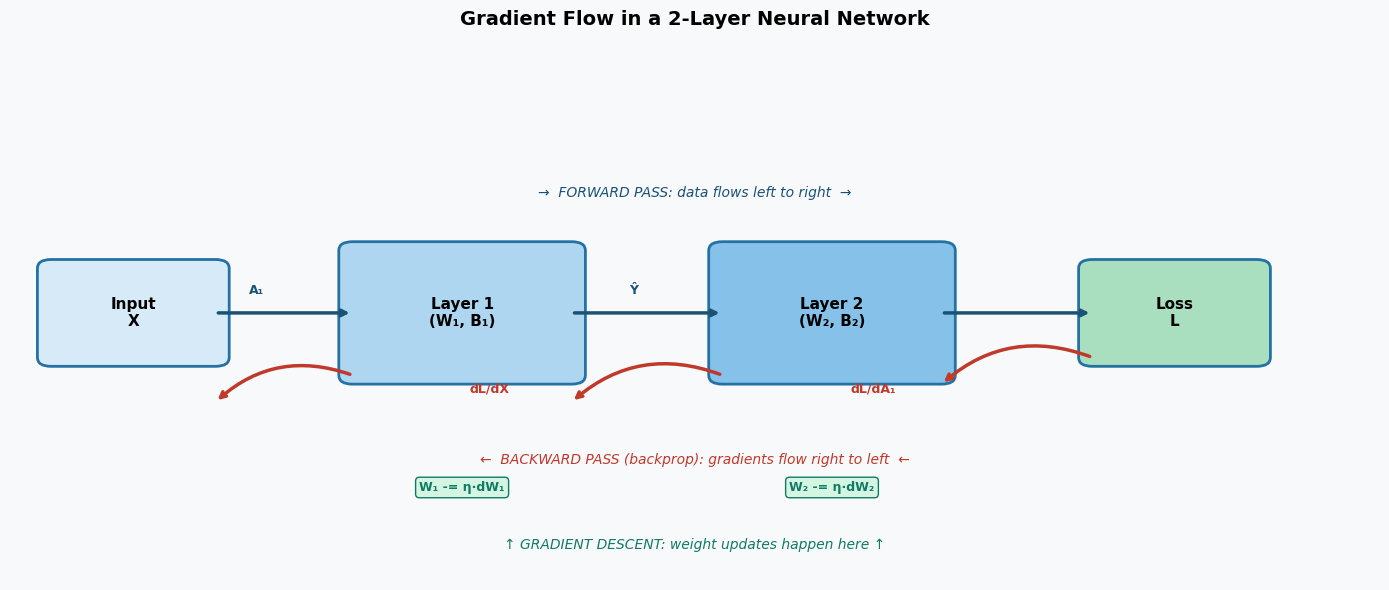

In [8]:
# ─────────────────────────────────────────────────────────────────
# GRADIENT FLOW VISUALISATION
# ─────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(14, 6))
ax.set_xlim(0, 10)
ax.set_ylim(0, 6)
ax.axis('off')
ax.set_facecolor('#F8F9FA')
fig.patch.set_facecolor('#F8F9FA')
ax.set_title("Gradient Flow in a 2-Layer Neural Network",
             fontsize=14, fontweight='bold', pad=15)

# ── Boxes ────────────────────────────────────────────────────────
boxes = [
    (0.3, 2.5, 1.2, 1.0, '#D6EAF8', 'Input\nX'),
    (2.5, 2.3, 1.6, 1.4, '#AED6F1', 'Layer 1\n(W₁, B₁)'),
    (5.2, 2.3, 1.6, 1.4, '#85C1E9', 'Layer 2\n(W₂, B₂)'),
    (7.9, 2.5, 1.2, 1.0, '#A9DFBF', 'Loss\nL'),
]

for (x, y, w, h, colour, text) in boxes:
    rect = mpatches.FancyBboxPatch((x, y), w, h,
        boxstyle='round,pad=0.1', facecolor=colour,
        edgecolor='#2471A3', linewidth=2)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, text, ha='center', va='center',
            fontsize=11, fontweight='bold')

# ── Forward arrows ───────────────────────────────────────────────
forward_arrows = [(1.5, 3.0, 1.0, 0), (4.1, 3.0, 1.1, 0), (6.8, 3.0, 1.1, 0)]
for (x, y, dx, dy) in forward_arrows:
    ax.annotate("", xy=(x+dx, y+dy), xytext=(x, y),
        arrowprops=dict(arrowstyle="->", color='#1A5276', lw=2.5))

ax.text(5.0, 4.3, "→  FORWARD PASS: data flows left to right  →",
        ha='center', fontsize=10, color='#1A5276', fontstyle='italic')

# ── Backward arrows ──────────────────────────────────────────────
backward_arrows = [
    (7.9, 2.5, -1.1, -0.3),
    (5.2, 2.3, -1.1, -0.3),
    (2.5, 2.3, -1.0, -0.3),
]
for (x, y, dx, dy) in backward_arrows:
    ax.annotate("", xy=(x+dx, y+dy), xytext=(x, y),
        arrowprops=dict(arrowstyle="->", color='#C0392B', lw=2.5,
                        connectionstyle='arc3,rad=0.3'))

ax.text(5.0, 1.3, "←  BACKWARD PASS (backprop): gradients flow right to left  ←",
        ha='center', fontsize=10, color='#C0392B', fontstyle='italic')

# ── Labels ───────────────────────────────────────────────────────
labels = [
    (1.8, 3.25, '#1A5276', 'A₁'),
    (4.55, 3.25, '#1A5276', 'Ŷ'),
    (6.3, 2.15, '#C0392B', 'dL/dA₁'),
    (3.5, 2.15, '#C0392B', 'dL/dX'),
]
for (x, y, colour, text) in labels:
    ax.text(x, y, text, ha='center', va='center',
            fontsize=9, color=colour, fontweight='bold')

# ── Weight update notes ──────────────────────────────────────────
for x_box, label in [(3.3, 'W₁ -= η·dW₁'), (6.0, 'W₂ -= η·dW₂')]:
    ax.text(x_box, 1.0, label, ha='center', fontsize=9,
            color='#117A65', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#D5F5E3', edgecolor='#117A65'))

ax.text(5.0, 0.35, "↑ GRADIENT DESCENT: weight updates happen here ↑",
        ha='center', fontsize=10, color='#117A65', fontstyle='italic')

plt.tight_layout()
plt.savefig('backprop_flow.png', dpi=120, bbox_inches='tight')
plt.show()

---
# PART 4 — The Full System: Solving XOR

---

## 4.1 Why XOR?

**XOR (Exclusive OR)** is a classic test problem because it is the *simplest* problem that a single straight line cannot solve.

The truth table:

| Input A | Input B | Output |
|:-------:|:-------:|:------:|
| 0       | 0       | **0**  |
| 0       | 1       | **1**  |
| 1       | 0       | **1**  |
| 1       | 1       | **0**  |

Try drawing these four points on a graph and drawing one straight line to separate the 0s from the 1s. You cannot do it.

A neural network with a **hidden layer** solves this by learning to *warp the space* — bending the coordinate system until the two classes become linearly separable. This is one of the most elegant demonstrations of what non-linearity buys you.

---

## 4.2 Building the Network Orchestrator

In [9]:
# ─────────────────────────────────────────────────────────────────
# THE NEURAL NETWORK ORCHESTRATOR
# ─────────────────────────────────────────────────────────────────

class NeuralNetwork:
    """
    Orchestrates a sequence of DenseLayer objects.
    
    The three methods map directly to the three phases:
      forward()              — runs data through all layers (left to right)
      backpropagate()        — sends gradients backwards (right to left)
      apply_gradient_descent() — updates all layer weights
    """
    
    def __init__(self):
        self.layers = []
    
    def add_layer(self, layer):
        self.layers.append(layer)
    
    def forward(self, X):
        """Pass input through every layer in order."""
        output = X
        for layer in self.layers:
            output = layer.forward(output)
        return output
    
    def backpropagate(self, loss_gradient):
        """
        Send the loss gradient BACKWARDS through layers.
        Each layer uses the incoming gradient to compute its own weight
        gradients (stored internally) and outputs a gradient for the
        layer below it.
        """
        gradient = loss_gradient
        for layer in reversed(self.layers):     # reversed! right-to-left
            gradient = layer.backward(gradient)
    
    def apply_gradient_descent(self, learning_rate):
        """Update every layer's parameters using stored gradients."""
        for layer in self.layers:
            layer.gradient_descent_step(learning_rate)


print("NeuralNetwork class defined.")
print()
print("Notice the clean separation:")
print("  backpropagate()          → calls layer.backward()  on each layer (COMPUTES gradients)")
print("  apply_gradient_descent() → calls layer.gradient_descent_step() (APPLIES them)")
print()
print("These two things are ALWAYS logically separate, even in PyTorch and TensorFlow.")

NeuralNetwork class defined.

Notice the clean separation:
  backpropagate()          → calls layer.backward()  on each layer (COMPUTES gradients)
  apply_gradient_descent() → calls layer.gradient_descent_step() (APPLIES them)

These two things are ALWAYS logically separate, even in PyTorch and TensorFlow.


---
## 4.3 The XOR Dataset and Network Architecture

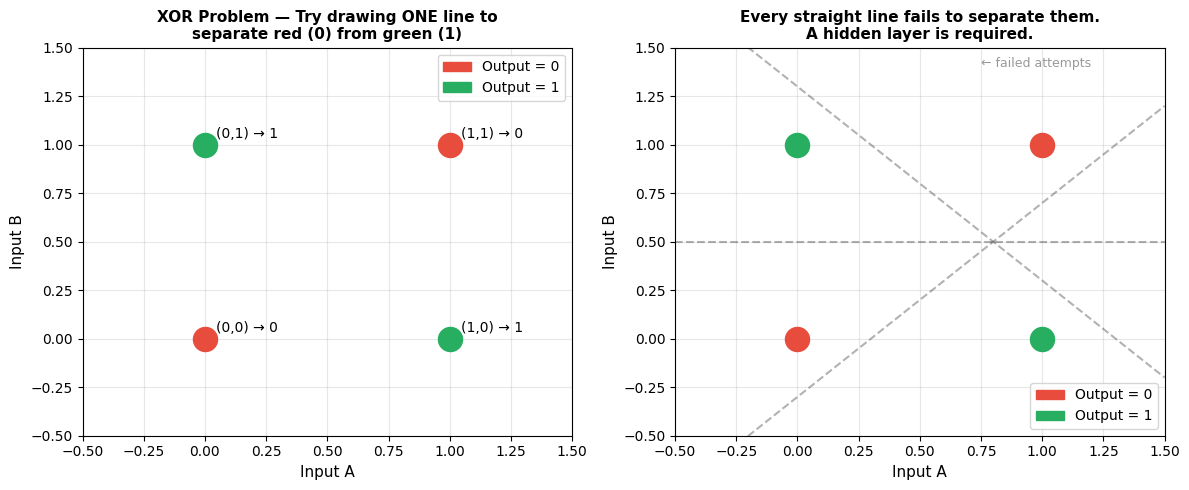

Network architecture:
  Input       : 2 features (A and B)
  Hidden layer: 4 neurons  (learns to warp the space)
  Output layer: 1 neuron   (binary prediction: 0 or 1)


In [10]:
# ─────────────────────────────────────────────────────────────────
# XOR DATASET
# ─────────────────────────────────────────────────────────────────

X_train = np.array([[0, 0],
                    [0, 1],
                    [1, 0],
                    [1, 1]], dtype=float)

y_train = np.array([[0],
                    [1],
                    [1],
                    [0]], dtype=float)

# ── Show why XOR is hard for linear models ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# XOR points
ax = axes[0]
colours = ['#E74C3C' if y == 0 else '#27AE60' for y in y_train.flatten()]
for i, (pt, col) in enumerate(zip(X_train, colours)):
    ax.scatter(*pt, color=col, s=300, zorder=5)
    label = f"({int(pt[0])},{int(pt[1])}) → {int(y_train[i][0])}"
    ax.annotate(label, pt, textcoords='offset points', xytext=(8, 5), fontsize=10)
ax.set_title("XOR Problem — Try drawing ONE line to\nseparate red (0) from green (1)",
             fontsize=11, fontweight='bold')
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(-0.5, 1.5)
ax.set_xlabel("Input A", fontsize=11)
ax.set_ylabel("Input B", fontsize=11)
ax.grid(True, alpha=0.3)
red_patch   = mpatches.Patch(color='#E74C3C', label='Output = 0')
green_patch = mpatches.Patch(color='#27AE60', label='Output = 1')
ax.legend(handles=[red_patch, green_patch], fontsize=10)

# Show that it's not linearly separable
ax2 = axes[1]
for i, (pt, col) in enumerate(zip(X_train, colours)):
    ax2.scatter(*pt, color=col, s=300, zorder=5)
# Draw some failed linear attempts
x_line = np.linspace(-0.5, 1.5, 50)
for slope, intercept, alpha in [(1, -0.3, 0.3), (-1, 1.3, 0.3), (0, 0.5, 0.3)]:
    ax2.plot(x_line, slope*x_line + intercept, 'k--', alpha=alpha, linewidth=1.5)
ax2.set_title("Every straight line fails to separate them.\nA hidden layer is required.",
              fontsize=11, fontweight='bold')
ax2.set_xlim(-0.5, 1.5)
ax2.set_ylim(-0.5, 1.5)
ax2.set_xlabel("Input A", fontsize=11)
ax2.set_ylabel("Input B", fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.legend(handles=[red_patch, green_patch], fontsize=10)
ax2.text(0.75, 1.4, "← failed attempts", fontsize=9, color='grey', alpha=0.8)

plt.tight_layout()
plt.savefig('xor_problem.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Build the network ─────────────────────────────────────────────
np.random.seed(42)   # reset for reproducible training
nn = NeuralNetwork()
nn.add_layer(DenseLayer(input_dim=2, output_dim=4))   # Hidden layer: 4 neurons
nn.add_layer(DenseLayer(input_dim=4, output_dim=1))   # Output layer: 1 neuron

print("Network architecture:")
print("  Input       : 2 features (A and B)")
print("  Hidden layer: 4 neurons  (learns to warp the space)")
print("  Output layer: 1 neuron   (binary prediction: 0 or 1)")

---
## 4.4 The Training Loop

This is where everything comes together. Study each of the three stages inside the loop:

1. **Forward pass** — data flows through the network → we get predictions → we compute the loss
2. **Backpropagation** — the loss gradient flows backwards → each layer computes its weight gradients
3. **Gradient descent** — every layer's weights are updated by a small step in the gradient direction

This three-stage loop repeats thousands of times. Each repetition is called an **epoch**.

In [11]:
# ─────────────────────────────────────────────────────────────────
# THE TRAINING LOOP
# ─────────────────────────────────────────────────────────────────

EPOCHS        = 10_000
LEARNING_RATE = 0.5

loss_history  = []

print(f"Starting training: {EPOCHS:,} epochs, learning rate = {LEARNING_RATE}")
print("=" * 60)

for epoch in range(EPOCHS):
    
    # ── STAGE 1: FORWARD PASS ─────────────────────────────────────
    # Data flows through every layer. Each layer activates its neurons.
    # At the end we have predictions (ŷ).
    predictions = nn.forward(X_train)
    
    # Compute the loss (MSE) — our single error score
    loss = mse_loss(predictions, y_train)
    loss_history.append(loss)
    
    # ── STAGE 2: BACKPROPAGATION ──────────────────────────────────
    # Derivative of MSE loss: dL/dŷ = (ŷ - y)
    # This is the gradient we hand to the output layer.
    # It says: "for each prediction, here is how far off you were and in which direction."
    loss_gradient = predictions - y_train
    nn.backpropagate(loss_gradient)
    
    # ── STAGE 3: GRADIENT DESCENT ────────────────────────────────
    # All layers now have their gradients stored.
    # We subtract η × gradient from every weight and bias.
    nn.apply_gradient_descent(LEARNING_RATE)
    
    # ── Progress readout ─────────────────────────────────────────
    if epoch == 0 or (epoch + 1) % 1000 == 0:
        print(f"  Epoch {epoch+1:6,} | Loss: {loss:.6f}")

print("=" * 60)
print(f"\nTraining complete.")
print(f"Initial loss : {loss_history[0]:.6f}")
print(f"Final loss   : {loss_history[-1]:.6f}")
print(f"Improvement  : {loss_history[0] / loss_history[-1]:.0f}× better")

Starting training: 10,000 epochs, learning rate = 0.5
  Epoch      1 | Loss: 0.134136
  Epoch  1,000 | Loss: 0.011183
  Epoch  2,000 | Loss: 0.001425
  Epoch  3,000 | Loss: 0.000701
  Epoch  4,000 | Loss: 0.000458
  Epoch  5,000 | Loss: 0.000338
  Epoch  6,000 | Loss: 0.000267
  Epoch  7,000 | Loss: 0.000220
  Epoch  8,000 | Loss: 0.000187
  Epoch  9,000 | Loss: 0.000162
  Epoch 10,000 | Loss: 0.000144

Training complete.
Initial loss : 0.134136
Final loss   : 0.000144
Improvement  : 934× better


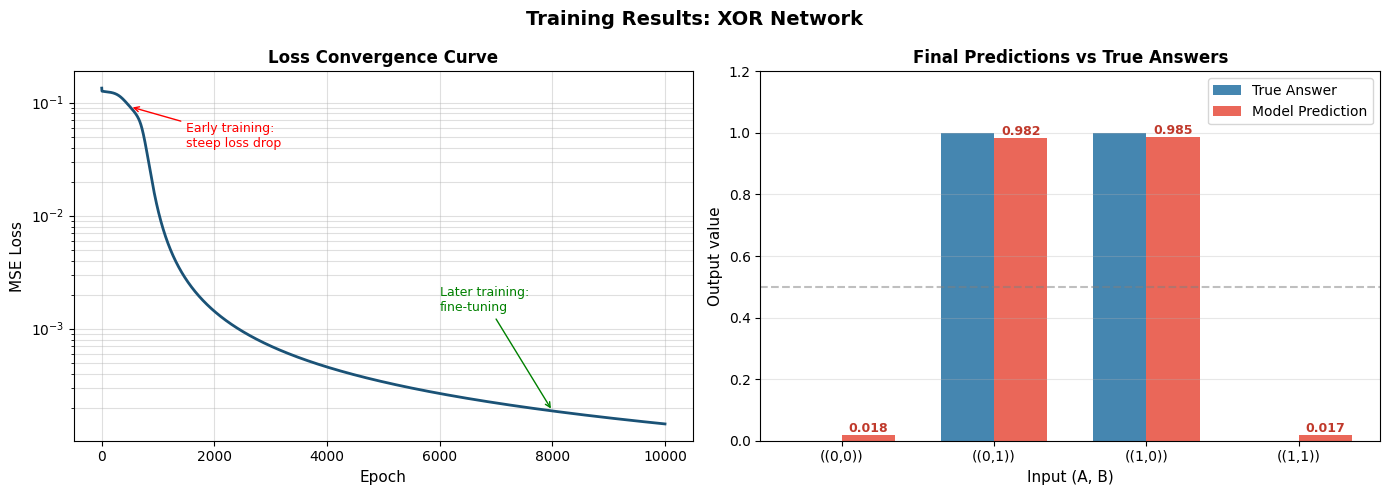


FINAL PREDICTIONS
  Input (0, 0) → Target: 0 | Prediction: 0.0180 → Rounded: 0  ✅
  Input (0, 1) → Target: 1 | Prediction: 0.9823 → Rounded: 1  ✅
  Input (1, 0) → Target: 1 | Prediction: 0.9853 → Rounded: 1  ✅
  Input (1, 1) → Target: 0 | Prediction: 0.0172 → Rounded: 0  ✅


In [12]:
# ─────────────────────────────────────────────────────────────────
# TRAINING RESULTS: LOSS CURVE + FINAL PREDICTIONS
# ─────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Training Results: XOR Network", fontsize=14, fontweight='bold')

# ── Loss curve ───────────────────────────────────────────────────
ax = axes[0]
ax.plot(loss_history, color='#1A5276', linewidth=2)
ax.set_title("Loss Convergence Curve", fontsize=12, fontweight='bold')
ax.set_xlabel("Epoch", fontsize=11)
ax.set_ylabel("MSE Loss", fontsize=11)
ax.set_yscale('log')   # log scale reveals the descent more clearly
ax.grid(True, alpha=0.4, which='both')

# Annotate key regions
ax.annotate("Early training:\nsteep loss drop",
    xy=(500, loss_history[500]), xytext=(1500, loss_history[0]*0.3),
    arrowprops=dict(arrowstyle='->', color='red'), fontsize=9, color='red')
ax.annotate("Later training:\nfine-tuning",
    xy=(8000, loss_history[8000]), xytext=(6000, loss_history[-1]*10),
    arrowprops=dict(arrowstyle='->', color='green'), fontsize=9, color='green')

# ── Predictions bar chart ────────────────────────────────────────
ax2 = axes[1]
final_preds = nn.forward(X_train).flatten()
targets_flat = y_train.flatten()
labels = [f"({int(x[0])},{int(x[1])})" for x in X_train]

x_positions = np.arange(len(labels))
width = 0.35
bars1 = ax2.bar(x_positions - width/2, targets_flat, width,
                label='True Answer', color='#2471A3', alpha=0.85)
bars2 = ax2.bar(x_positions + width/2, final_preds,  width,
                label='Model Prediction', color='#E74C3C', alpha=0.85)

# Add value labels on top of bars
for bar, val in zip(bars2, final_preds):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{val:.3f}", ha='center', fontsize=9, fontweight='bold', color='#C0392B')

ax2.set_title("Final Predictions vs True Answers", fontsize=12, fontweight='bold')
ax2.set_xticks(x_positions)
ax2.set_xticklabels([f"({l})" for l in labels], fontsize=10)
ax2.set_xlabel("Input (A, B)", fontsize=11)
ax2.set_ylabel("Output value", fontsize=11)
ax2.set_ylim(0, 1.2)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')
ax2.axhline(0.5, color='grey', linestyle='--', alpha=0.5, label='Decision boundary = 0.5')

plt.tight_layout()
plt.savefig('training_results.png', dpi=120, bbox_inches='tight')
plt.show()

print("\n" + "=" * 55)
print("FINAL PREDICTIONS")
print("=" * 55)
for i, (inp, pred, tgt) in enumerate(zip(X_train, final_preds, targets_flat)):
    status = "✅" if abs(pred - tgt) < 0.1 else "⚠️"
    rounded = round(pred)
    print(f"  Input ({int(inp[0])}, {int(inp[1])}) → "
          f"Target: {int(tgt)} | Prediction: {pred:.4f} → Rounded: {rounded}  {status}")

---
## 4.5 The Decision Boundary — What the Network Learned

The network learned to *warp* the 2D input space. The decision boundary below shows, for every possible (A, B) input, whether the network would classify it as 0 (red) or 1 (green).

Notice how the boundary is **not a straight line** — it's a curved, non-linear region. This is what the hidden layer's non-linear activations make possible.

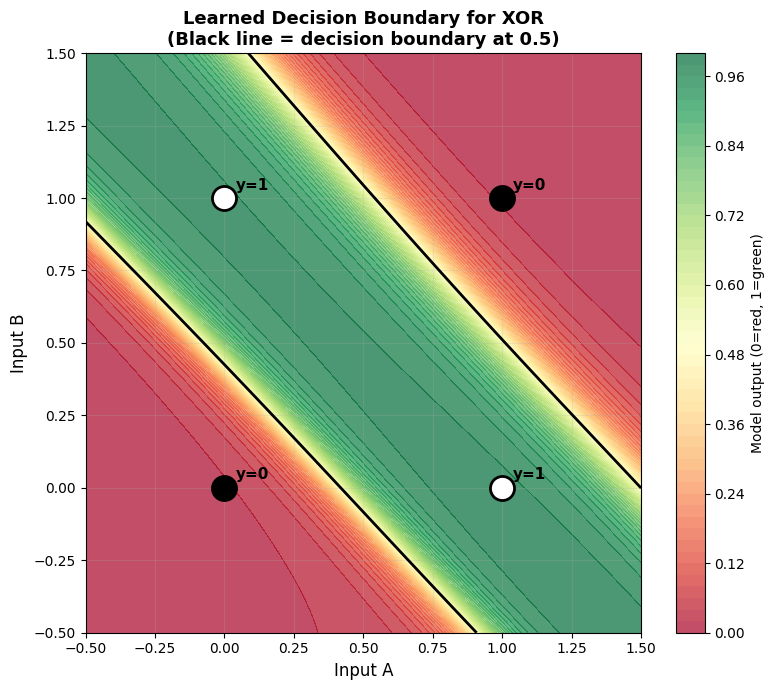

📖 What you're seeing:
  The black curve is the decision boundary — the network's learned dividing line.
  It is NOT a straight line. This non-linearity comes from the hidden layer.
  White dots (y=1) are surrounded by green; black dots (y=0) by red.
  The network has correctly separated all four XOR cases.


In [13]:
# ─────────────────────────────────────────────────────────────────
# DECISION BOUNDARY VISUALISATION
# ─────────────────────────────────────────────────────────────────

resolution = 300
x1 = np.linspace(-0.5, 1.5, resolution)
x2 = np.linspace(-0.5, 1.5, resolution)
X1, X2 = np.meshgrid(x1, x2)
grid = np.c_[X1.ravel(), X2.ravel()]

grid_preds = nn.forward(grid).reshape(resolution, resolution)

fig, ax = plt.subplots(figsize=(8, 7))

# Filled contour: red = predict 0, green = predict 1
contour = ax.contourf(X1, X2, grid_preds, levels=50,
                       cmap='RdYlGn', alpha=0.7, vmin=0, vmax=1)
plt.colorbar(contour, ax=ax, label='Model output (0=red, 1=green)')

# Decision boundary line at 0.5
ax.contour(X1, X2, grid_preds, levels=[0.5], colors='black', linewidths=2)

# Plot the training points
point_colours = ['white' if y == 1 else 'black' for y in y_train.flatten()]
for pt, col, tgt in zip(X_train, point_colours, y_train.flatten()):
    ax.scatter(*pt, color=col, s=300, zorder=10, edgecolors='black', linewidth=2)
    ax.annotate(f"y={int(tgt)}", pt, textcoords='offset points',
                xytext=(8, 6), fontsize=11, fontweight='bold')

ax.set_title("Learned Decision Boundary for XOR\n"
             "(Black line = decision boundary at 0.5)",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Input A", fontsize=12)
ax.set_ylabel("Input B", fontsize=12)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('decision_boundary.png', dpi=120, bbox_inches='tight')
plt.show()

print("📖 What you're seeing:")
print("  The black curve is the decision boundary — the network's learned dividing line.")
print("  It is NOT a straight line. This non-linearity comes from the hidden layer.")
print("  White dots (y=1) are surrounded by green; black dots (y=0) by red.")
print("  The network has correctly separated all four XOR cases.")

---
# PART 5 — Your Summary Notes

---

This section is written to be **copied into your personal notes**. Each concept is summarised in one clear paragraph, plus a one-sentence TL;DR.

---

## 📝 Note 1: What is a Loss Function?

A loss function is a mathematical score that measures how wrong a model's predictions are. It takes the model's output and the true answer, and returns a single number — the loss — where lower is better and zero means perfect. The choice of loss function depends on the task: Mean Squared Error (MSE) is natural for predicting continuous values (like prices or temperatures), while Binary Cross-Entropy is natural for classification tasks where the output is a probability. The loss function is the feedback signal that drives all learning.

**TL;DR:** *The loss function is the model's report card — one number that says "this is how wrong you are."*

---

## 📝 Note 2: What is Gradient Descent?

Gradient descent is an optimisation algorithm that finds the values of model parameters (weights and biases) that minimise the loss. It works by computing the gradient — the slope of the loss with respect to each weight — and then nudging each weight in the downhill direction. The size of each nudge is controlled by the learning rate η. A learning rate that is too large causes the model to overshoot the minimum; too small and training is painfully slow. Gradient descent is repeated for many epochs until the loss converges to a minimum.

**The update rule:** `weight_new = weight_old − η × gradient`

**TL;DR:** *Gradient descent is the stepping rule that moves weights downhill on the loss landscape.*

---

## 📝 Note 3: What is Backpropagation?

Backpropagation is the algorithm that computes the gradient of the loss with respect to every weight in the network. Because a network has many layers, the loss is far removed from the earlier layers' weights. Backpropagation solves this by applying the **chain rule** of calculus: it starts at the loss, computes how the output layer's weights affected the loss, then passes that gradient backwards to the previous layer, which uses it to compute its own weight gradients, and so on. Crucially, values computed during the forward pass (the layer inputs and activation outputs) are cached so they can be reused during the backward pass.

**TL;DR:** *Backpropagation is the algorithm that traces the chain of causes from loss back to each weight.*

---

## 📝 Note 4: Backpropagation vs Gradient Descent — The Distinction

These two things are often confused, but they are completely different:

| | Backpropagation | Gradient Descent |
|--|--|--|
| **What it is** | An information routing algorithm | An optimisation algorithm |
| **What it does** | Computes the gradients | Uses those gradients to update weights |
| **Operates on** | The network's computation graph | The network's parameter values |
| **Analogy** | A GPS that calculates which direction is downhill | The act of actually taking a step in that direction |

Backpropagation computes the map. Gradient descent moves on it.

---

## 📝 Note 5: The Chain Rule in One Sentence

If A affects B and B affects C, then how A affects C is found by multiplying: (how A affects B) × (how B affects C). In a neural network, this means the gradient of the loss with respect to an early layer's weights is the product of many small local gradients chained together.

---

## 📝 Note 6: The Full Training Loop — In Order

```
FOR each epoch:
  1. FORWARD PASS
     Feed input X through every layer → get predictions ŷ
     Cache each layer's input and activated output

  2. COMPUTE LOSS
     loss = loss_function(ŷ, y_true)
     loss_gradient = derivative of loss_function w.r.t. ŷ

  3. BACKPROPAGATION
     Pass loss_gradient backwards through every layer (reversed order)
     Each layer uses the chain rule to compute:
       - its own weight gradients (dW, dB)  — stored for step 4
       - the gradient to pass to the layer below

  4. GRADIENT DESCENT
     For each layer:
       W = W - η × dW
       B = B - η × dB
```

---

## 📝 Note 7: Key Terms Glossary

| Term | Definition |
|------|------------|
| **Weight (W)** | A learnable number that scales a connection between neurons |
| **Bias (B)** | A learnable offset added to the neuron's input, shifts the activation threshold |
| **Activation function** | A non-linear gate (e.g. sigmoid, ReLU) that allows the network to learn curved boundaries |
| **Epoch** | One complete pass over the entire training dataset |
| **Learning rate (η)** | Step size for gradient descent — controls how big each weight update is |
| **Gradient** | The slope of the loss with respect to a parameter — tells us which direction increases the loss |
| **Loss landscape** | The imaginary surface where the x-axes are weight values and the y-axis is the loss |
| **Convergence** | When the loss stops decreasing — the model has found a minimum |
| **Vanishing gradient** | When gradients become tiny in early layers because each layer's small gradient is multiplied, causing learning to stall |
| **Xavier initialisation** | A weight initialisation scheme that keeps activation variances healthy across layers |

In [ ]:
# ─────────────────────────────────────────────────────────────────
# FINAL SUMMARY PRINTOUT
# ─────────────────────────────────────────────────────────────────

print("=" * 60)
print("COMPLETE SUMMARY")
print("=" * 60)

final_preds = nn.forward(X_train)
final_loss = mse_loss(final_preds, y_train)

print(f"\n📊 Training Statistics")
print(f"   Total epochs      : {EPOCHS:,}")
print(f"   Learning rate     : {LEARNING_RATE}")
print(f"   Initial loss      : {loss_history[0]:.6f}")
print(f"   Final loss        : {final_loss:.8f}")

print(f"\n🎯 Final Predictions")
all_correct = True
for inp, pred, tgt in zip(X_train, final_preds.flatten(), y_train.flatten()):
    rounded = round(float(pred))
    correct = rounded == int(tgt)
    if not correct:
        all_correct = False
    status = "✅ CORRECT" if correct else "❌ WRONG"
    print(f"   ({int(inp[0])}, {int(inp[1])}) → true: {int(tgt)}, "
          f"predicted: {pred:.4f} (→ {rounded})  {status}")

print()
if all_correct:
    print("🏆 All XOR cases solved correctly!")
    print("   The network learned a non-linear mapping from scratch.")
print()
print("What was used:")
print("  ✔  Loss function (MSE) — measured the error")
print("  ✔  Backpropagation — computed gradients via chain rule")
print("  ✔  Gradient descent — updated weights using those gradients")
print("  ✔  Sigmoid activation — introduced the non-linearity needed for XOR")
print()
print("Everything you see in PyTorch, TensorFlow, or JAX is this loop,")
print("scaled up and optimised — but conceptually identical.")